# Horizon perturbations from antenna-position error

Baseline horizon elevation profile $\alpha_h(\mathrm{az})$ (panel a) and the
change $\Delta\alpha_h = \alpha_h^{\mathrm{shift}} - \alpha_h^{\mathrm{nominal}}$
for +1 m antenna displacements East / North / Up (panel b). A 1 m move changes
the horizon by $\lesssim 0.1^\circ$ (RMS) over most azimuths, reaching
$0.85^\circ$ at the steep cliff edges east of the antenna (where a lateral move
slides a near-vertical horizon edge sideways); raising the antenna (Up +1 m)
lowers the horizon by a broad negative offset.


Profiles are computed with `eigsep_terrain.calc_horizon` on the Marjum DEM.
Azimuth is $\mathrm{atan2}(E, N)$, North$\to$East.

Data: `horizon_perturbations.npz` (keys `names`, `az_grid`, `alpha_h`). Produces
`horizon_perturbations_1col.pdf`, the single-column figure used in the paper.
The spectral consequence of these shifts is `horizon_shift.ipynb`; the full
derivation of both is
`mock_analysis/horizon_position/notebooks/horizon_shift.ipynb`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import eigsep_style as es

In [2]:
d = np.load("horizon_perturbations.npz", allow_pickle=True)
names = [str(n) for n in d["names"]]
az = np.degrees(d["az_grid"])          # azimuth grid [deg]
alpha = np.degrees(d["alpha_h"])       # horizon elevation per position [deg]
print(len(names), "positions on", az.size, "azimuths")

19 positions on 46080 azimuths


In [3]:
# Azimuth width of the running mean both panels are drawn through, read from
# the deposit rather than hard-coded here, so the figure cannot drift from the
# value the npz advertises. It is 360/258 deg: the MWSS beam grid carries
# 2*(lmax + 1) = 258 azimuths at lmax = 128, which is where the simulations
# sample the horizon.
SMOOTH_DEG = float(d["smooth_deg"])


def smooth_azimuth(y, az, width_deg=SMOOTH_DEG):
    """Circular running mean of ``y`` over ``width_deg`` of azimuth.

    A running mean on the stored grid, not a bin average. Both apply the same
    low-pass, but a bin average also decimates, which turns the curve into a
    staircase at the bin scale (point-to-point roughness 0.29 vs 0.0029 here).
    """
    n = int(round(width_deg / (az[1] - az[0])))
    k = np.ones(n) / n
    return np.convolve(np.r_[y[-n:], y, y[:n]], k, mode="same")[n:-n]


def build_horizon_figure(az, alpha, names, out_path):
    """Single-column horizon figure: baseline profile (a), +1 m shifts (b).

    Both panels are smoothed in azimuth to ``SMOOTH_DEG``, the resolution at
    which the simulations sample the horizon. Finer structure is not a response
    to the antenna moving -- see the notes above for the antisymmetry and
    linearity tests it fails -- and no quantity in the paper is computed from
    it. Smoothing panel (a) is free: it leaves the mean horizon unchanged to
    four decimals and shifts the open-sky solid angle by 1e-5.

    Font sizes are set per-artist rather than through ``plt.rc_context``.
    ``rc_context`` restores the ``backend`` rcParam on exit, which resets the
    inline backend's post-execute hook and silently stops every *later* cell
    from displaying its figure.
    """
    # Okabe-Ito colours, chosen to stay clear of the orange baseline fill.
    SHIFTS = [
        ("x_p_1", "East +1 m", "#0072B2"),   # blue
        ("y_p_1", "North +1 m", "#CC79A7"),  # reddish purple
        ("z_p_1", "Up +1 m", "#009E73"),     # bluish green
    ]
    FILL = "#c56a39"
    FS = 8                                   # single-column base font size
    base = smooth_azimuth(alpha[names.index("nominal")], az)

    fig, (axt, axb) = es.figure(
        cols=1, height_in=3.9720, nrows=2, ncols=1, sharex=True,
        gridspec_kw=dict(height_ratios=[1.822, 1.0]),
    )

    axt.fill_between(az, 0, base, color=FILL, lw=0)
    axt.plot(az, base, color="black", lw=0.8)
    axt.set_ylabel("Horizon Angle [deg]", fontsize=FS)
    axt.set_ylim(0, 40)
    axt.set_axisbelow(False)   # gridlines on top of the opaque fill

    for tag, lbl, c in SHIFTS:
        axb.plot(az, smooth_azimuth(alpha[names.index(tag)], az) - base,
                 color=c, lw=0.6, label=lbl)
    axb.set_ylabel(r"$\Delta$ Horizon [deg]", fontsize=FS)
    axb.set_xlabel("Azimuthal Angle [deg]", fontsize=FS)
    # Limits track the data's own span, -0.34 to +0.85 deg, which is not
    # symmetric; symmetric limits would fit the same peak only at +/-0.9 and
    # buy back no space. The legend sits over az > 190 deg, where no curve
    # exceeds 0.26 deg, so the +0.85 deg East cliff at az 170 needs no
    # headroom above it.
    axb.set_ylim(-0.4, 0.9)
    axb.set_yticks([-0.4, 0.0, 0.4, 0.8])
    axb.legend(ncol=2, loc="upper right", fontsize=6.0, columnspacing=0.8,
               handlelength=1.2, handletextpad=0.4, borderpad=0.3,
               labelspacing=0.3, framealpha=0.9)

    for ax, tag in ((axt, "(a)"), (axb, "(b)")):
        ax.set_xlim(0, 360)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=FS)
        ax.text(0.012, 0.93, tag, transform=ax.transAxes, va="top", fontsize=FS)

    es.save(fig, out_path)
    return fig


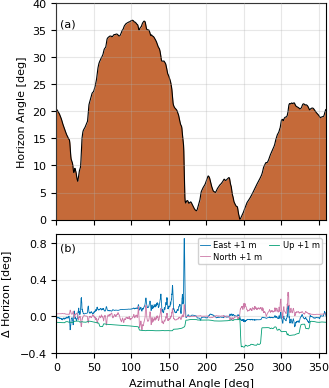

In [4]:
fig = build_horizon_figure(az, alpha, names, "horizon_perturbations_1col.pdf")